In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WELFake_Dataset.csv')

In [ ]:
df


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
title,object
text,object
label,int64


In [ ]:
df.shape

(72134, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [ ]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


In [ ]:
df.nunique()

,0
Unnamed: 0,72134
title,62347
text,62718
label,2


In [ ]:
print(df['label'].value_counts())

label
1    37106
0    35028
Name: count, dtype: int64


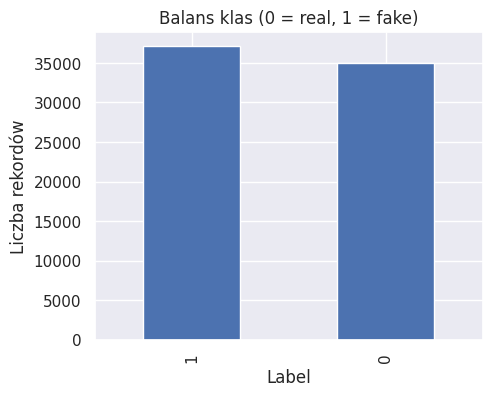

In [ ]:
plt.figure(figsize=(5,4))
df['label'].value_counts().plot(kind='bar')
plt.title("Balans klas (0 = real, 1 = fake)")
plt.xlabel("Label")
plt.ylabel("Liczba rekordów")
plt.show()

In [ ]:
df['title_len'] = df['title'].astype(str).apply(len)
df['title_words'] = df['title'].astype(str).apply(lambda x: len(x.split()))

df['text_len'] = df['text'].astype(str).apply(len)
df['text_words'] = df['text'].astype(str).apply(lambda x: len(x.split()))

In [ ]:
print("Średnia długość tytułu (znaki):", df['title_len'].mean())
print("Średnia długość tekstu (znaki):", df['text_len'].mean())


Średnia długość tytułu (znaki): 76.56752710233732
Średnia długość tekstu (znaki): 3268.3894557351596


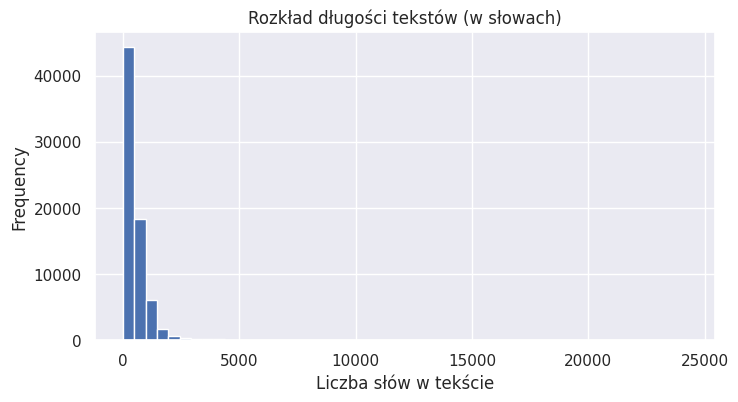

In [ ]:
plt.figure(figsize=(8,4))
df['text_words'].plot(kind='hist', bins=50)
plt.title("Rozkład długości tekstów (w słowach)")
plt.xlabel("Liczba słów w tekście")
plt.show()

<Figure size 600x400 with 0 Axes>

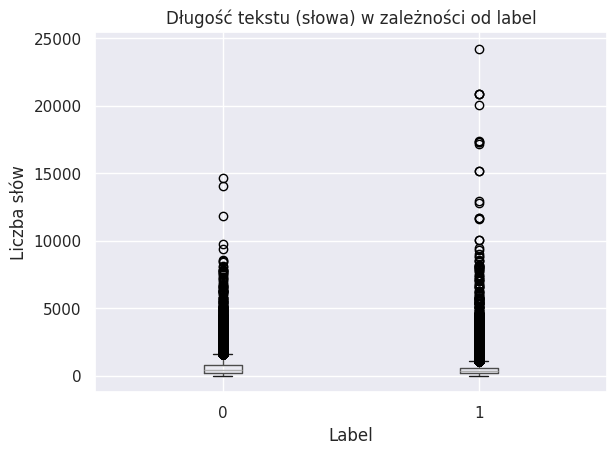

In [ ]:
plt.figure(figsize=(6,4))
df.boxplot(column='text_words', by='label')
plt.title("Długość tekstu (słowa) w zależności od label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Liczba słów")
plt.show()

In [ ]:
from collections import Counter
import re

def tokenize(text):
    text = re.sub(r"[^a-zA-Z ]", "", str(text))
    return text.lower().split()

all_words = []
df['text'].dropna().apply(lambda x: all_words.extend(tokenize(x)))

word_freq = Counter(all_words).most_common(20)
print("Top 20 słów:", word_freq)

Top 20 słów: [('the', 2214007), ('to', 1101613), ('of', 990146), ('and', 907999), ('a', 883103), ('in', 751649), ('that', 516935), ('is', 377994), ('for', 362440), ('on', 360210), ('it', 260852), ('he', 257204), ('with', 250860), ('was', 244853), ('as', 234123), ('said', 228973), ('by', 197941), ('s', 189375), ('his', 188194), ('have', 179351)]


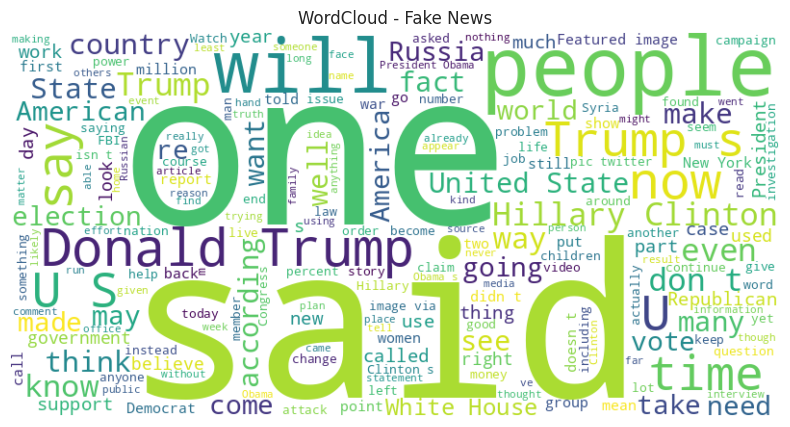

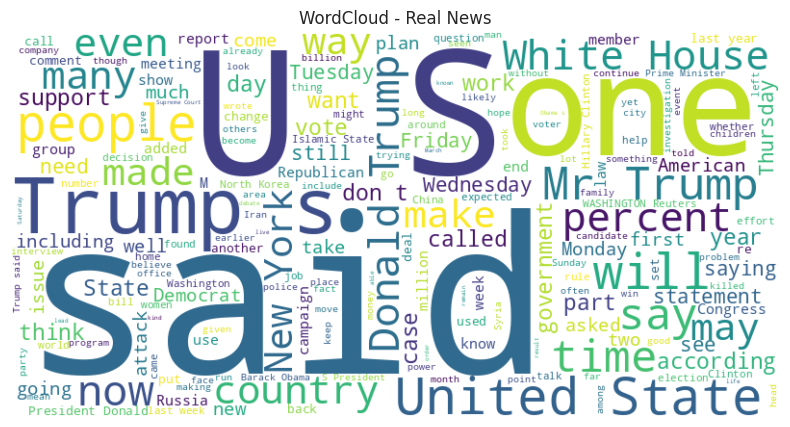

In [ ]:
from wordcloud import WordCloud
from collections import Counter
import re

text_fake = " ".join(df[df['label']==1]['text'].dropna().astype(str))
text_real = " ".join(df[df['label']==0]['text'].dropna().astype(str))

wc_fake = WordCloud(width=800, height=400, background_color="white").generate(text_fake)
wc_real = WordCloud(width=800, height=400, background_color="white").generate(text_real)

plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Fake News")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(wc_real, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Real News")
plt.show()

1. **Balans klas** – dane są w miarę zrównoważone (klasa 0 i 1 mają podobną liczność), co jest korzystne dla uczenia modeli klasyfikacyjnych.  
2. **Braki danych** – w kolumnie `title` i `text` występują pewne braki/puste wartości.  
3. **Długość tekstów** – artykuły mają bardzo zróżnicowaną długość; większość mieści się w przedziale kilkuset słów, ale występują outliery (bardzo krótkie i bardzo długie teksty).  
4. **Długość tytułów** – tytuły są znacznie krótsze (średnio kilkanaście słów); widać różnice między klasami, fake newsy częściej mają krótsze i bardziej sensacyjne nagłówki.  
5. **Częstość słów** – w obu klasach pojawiają się wspólne, ogólne słowa (np. „Obama”, „Trump”), ale w fake newsach częściej występują słowa nacechowane emocjonalnie i wykrzykniki.  
6. **WordCloud** – wizualizacja słów pokazuje, że fake newsy mają tendencję do powtarzania mocnych, chwytliwych fraz, natomiast prawdziwe newsy są bardziej zróżnicowane.  
7. **Outliery** – bardzo krótkie rekordy (np. brak tytułu albo tylko jedno zdanie w tekście) mogą wymagać usunięcia lub specjalnego traktowania przy uczeniu modelu.